In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fingeprint-image/valid/AB-/cluster_5_763_BMP.rf.790fa983f3b66b64cf18a1b2fdff729f.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_1142_BMP.rf.d318b6523cc15199b03f2768e0f796e2.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_507_BMP.rf.6b8462239d73163d9a1bcf2fd43f4134.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_2036_BMP.rf.245c88fa65486730d98e6b0709bda380.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_5890_BMP.rf.61c6fe98ac5804d972117811527e6748.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_5060_BMP.rf.5934f53119f0c90230f238e06854fa5f.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_4837_BMP.rf.5fb02be9603c680ee92abbd1a2097c26.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_5017_BMP.rf.e7ae5ad85c7873c36bf2bcc65eb21577.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_769_BMP.rf.8e25be3010099f5656cfe01d73b7e420.jpg
/kaggle/input/fingeprint-image/valid/AB-/cluster_5_71_BMP.rf.61409d59baf3143be941d45348f3e2f6.jpg
/kagg

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import shutil
from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import shutil
from collections import Counter
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-06-23 02:02:52.891200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750644173.086723      77 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750644173.146175      77 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Define input shape based on your fingerprint image size
input_shape = (224, 224, 3)

# Load pre-trained VGG19 without the top classification layers
base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False


I0000 00:00:1750644186.128927      77 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)  # Example: 8 blood group classes

High_Acc_model = Model(inputs=base_model.input, outputs=output)


In [5]:
High_Acc_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [6]:
Batch_Size=32

# Setup directory paths if needed
train_dir = "/kaggle/input/fingeprint-image/train"
val_dir = "/kaggle/input/fingeprint-image/valid"
test_dir="/kaggle/input/fingeprint-image/test"
# Data generators
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,target_size=(224, 224),
    batch_size=Batch_Size, class_mode='sparse')

val_data = datagen.flow_from_directory(
    val_dir, target_size=(224, 224),
    batch_size=Batch_Size, class_mode='sparse')

test_data = datagen.flow_from_directory(
    test_dir, target_size=(224, 224),
    batch_size=Batch_Size, class_mode='sparse',shuffle=False)

Found 12570 images belonging to 8 classes.
Found 1196 images belonging to 8 classes.
Found 599 images belonging to 8 classes.


In [7]:
#2.Data class distribution
# Get class names
class_indices = train_data.class_indices
class_names = list(class_indices.keys())

# Initialize counter
class_counts = Counter()

# Loop through train_data once (avoid looping forever!)
for i in range(len(train_data)):
    _, labels = train_data[i]
    for label in labels:
        class_counts[int(label)] += 1

# Print class distribution
print("Class Distribution:")
for i, count in class_counts.items():
    print(f"{class_names[i]}: {count}")


Class Distribution:
O+: 1746
A+: 1197
B-: 1602
A-: 2085
B+: 1359
O-: 1494
AB-: 1605
AB+: 1482


In [8]:
# Get the maximum count
max_count = max(class_counts.values())
print(f"\nMaximum number of samples in any class (Train Data): {max_count}")


Maximum number of samples in any class (Train Data): 2085


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

datagen = ImageDataGenerator(rescale=1./255)

# Load train data without shuffling
raw_train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode='sparse',
    shuffle=False
)

# Store all images and labels
images = []
labels = []

for i in range(len(raw_train_data)):
    img, label = raw_train_data[i]
    images.append(img[0])
    labels.append(int(label[0]))

images = np.array(images)
labels = np.array(labels)


Found 12570 images belonging to 8 classes.


In [10]:
from sklearn.utils import resample

# Combine images and labels
data = list(zip(images, labels))

# Separate by class
class_data = {class_idx: [] for class_idx in np.unique(labels)}
for img, label in data:
    class_data[label].append(img)

# Oversample
balanced_images = []
balanced_labels = []

for class_idx, img_list in class_data.items():
    # Resample to match the max count
    resampled_imgs = resample(
        img_list,
        replace=True,
        n_samples=max_count,
        random_state=42
    )
    balanced_images.extend(resampled_imgs)
    balanced_labels.extend([class_idx] * max_count)

# Final balanced data
balanced_images = np.array(balanced_images)
balanced_labels = np.array(balanced_labels)

print("Balanced training samples:", len(balanced_labels))


Balanced training samples: 16680


In [11]:
balanced_datagen = ImageDataGenerator()

balanced_train_data = balanced_datagen.flow(
    balanced_images,
    balanced_labels,
    batch_size=Batch_Size
)

In [12]:
# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss', # monitor validation loss is improving or not
    factor = 0.5,         #Reduce the learning rate by 0.5
    patience =3,          #Wait for 3 epochs without improvement then take action
    verbose = 1,          #Print a masage when learning rate reduce
    min_lr = 1e-6         #menimum learning rate to avoid too small value , that is the minium learning rate 
)

# Define Earilstopping callbacks to stop traning when validation loss does not improve
#Collbacks for overfitting
early_stop = EarlyStopping(
    monitor = 'val_loss', # monitor validation loss
    patience =5,          #stop training after 5 epochs without improvement 
    verbose = 1,          #Print a masage when traning is stop
    restore_best_weights =True # Restore the model weight from best epoch(Store lowest validation loss )
)

In [13]:
# Fit model
High_Acc=High_Acc_model.fit(
    balanced_train_data, 
    validation_data=val_data, 
    epochs=50,
    callbacks=[reduce_lr,early_stop]
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1750644330.067589     126 service.cc:148] XLA service 0x7e992c00d200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750644330.068334     126 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1750644330.491053     126 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/522 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - accuracy: 0.0938 - loss: 2.7890   

I0000 00:00:1750644338.820180     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


522/522 ━━━━━━━━━━━━━━━━━━━━ 70s 114ms/step - accuracy: 0.3131 - loss: 1.8171 - val_accuracy: 0.5853 - val_loss: 1.1900 - learning_rate: 0.0010
Epoch 2/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - accuracy: 0.5840 - loss: 1.1223 - val_accuracy: 0.6589 - val_loss: 0.9391 - learning_rate: 0.0010
Epoch 3/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.6650 - loss: 0.9120 - val_accuracy: 0.7074 - val_loss: 0.8310 - learning_rate: 0.0010
Epoch 4/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.7006 - loss: 0.8124 - val_accuracy: 0.7057 - val_loss: 0.7772 - learning_rate: 0.0010
Epoch 5/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - accuracy: 0.7217 - loss: 0.7380 - val_accuracy: 0.7249 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 6/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 95ms/step - accuracy: 0.7362 - loss: 0.6957 - val_accuracy: 0.7550 - val_loss: 0.6661 - learning_rate: 0.0010
Epoch 7/50
522/522 ━━━━━━━━━━━━━━━━━━━━ 50s 96ms/step - accuracy: 0.7449 - loss: 0.679

In [14]:
test_loss, test_acc = High_Acc_model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# high_acc_eval = High_Acc.evaluate(val_dataset)
# print(f"High Accuracy Model - Loss: {high_acc_eval[0]}, Accuracy: {high_acc_eval[1]}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 431ms/step - accuracy: 0.7844 - loss: 0.6003
Test Accuracy: 0.7997
Test Loss: 0.5224


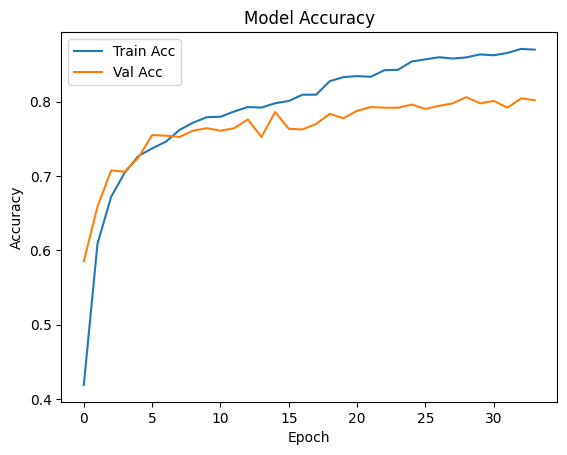

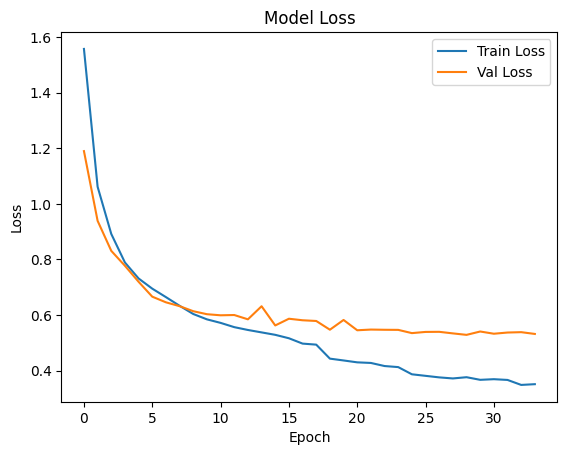

In [15]:
# Accuracy
plt.plot(High_Acc.history['accuracy'], label='Train Acc')
plt.plot(High_Acc.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Loss
plt.plot(High_Acc.history['loss'], label='Train Loss')
plt.plot(High_Acc.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


Classification Report:
              precision    recall  f1-score   support

          A+       0.87      0.80      0.83        60
          A-       0.75      0.70      0.72        96
         AB+       0.80      0.80      0.80        82
         AB-       0.78      0.91      0.84        76
          B+       0.82      0.85      0.84        60
          B-       0.83      0.89      0.86        66
          O+       0.79      0.71      0.75        92
          O-       0.78      0.81      0.79        67

    accuracy                           0.80       599
   macro avg       0.80      0.81      0.80       599
weighted avg       0.80      0.80      0.80       599



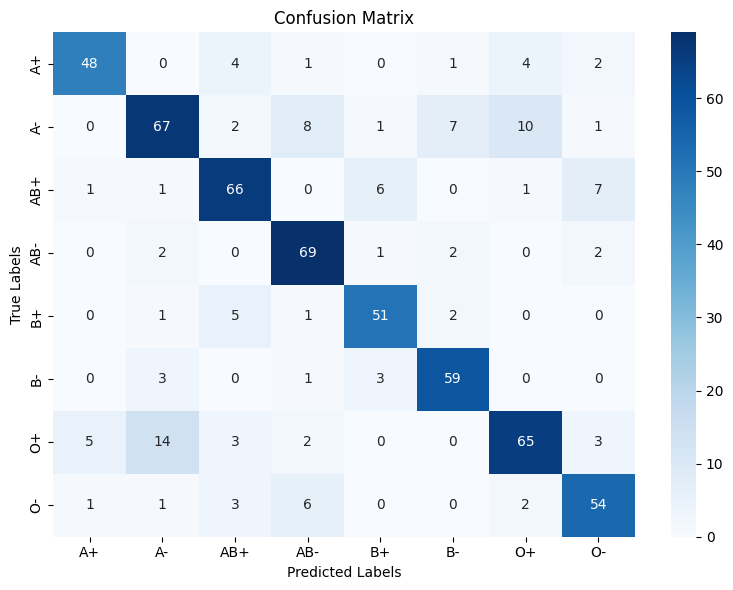

In [16]:
# Initialize empty lists
y_true = []
y_pred = []

# Make predictions on test data
for i in range(len(test_data)):
    images, labels = test_data[i]  # Get batch
    predictions = High_Acc_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.astype(int))           # Ensure int labels
    y_pred.extend(predicted_labels)

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


In [17]:
High_Acc_model.save('VGG19_model.h5') # The model will be saved  as 'My_model.h5'
print("Model saved  as HDF5 format.")

Model saved  as HDF5 format.
